LEVEL 2 - TASK 2: DECISION TREE CLASSIFIER

STEP 1: LOAD AND PREPARE DATA
❌ Iris dataset not found! Creating sample data...

📌 DATASET INFORMATION:
Shape: 150 rows × 4 features
Classes: ['setosa' 'versicolor' 'virginica']

📌 Training set: 120 samples
📌 Testing set: 30 samples

STEP 2: TRAIN DECISION TREE WITHOUT PRUNING
✅ Model trained successfully!

📌 Performance (No Pruning):
   • Accuracy: 0.2333
   • Tree depth: 13
   • Number of leaves: 53

STEP 3: PRUNE TREE - FIND OPTIMAL DEPTH

📌 Testing different tree depths:
--------------------------------------------------
Depth      Train Acc    Test Acc    
--------------------------------------------------
2          0.4917       0.2667
3          0.5500       0.2333
4          0.5917       0.2667
5          0.6917       0.3667
6          0.7750       0.2667
7          0.8500       0.2667
8          0.8917       0.2333
Unlimited  1.0000       0.2333

🏆 Best depth: 5 (Test accuracy: 0.3667)

STEP 4: TRAIN PRUNED DECISION TREE
✅ Pruned tre

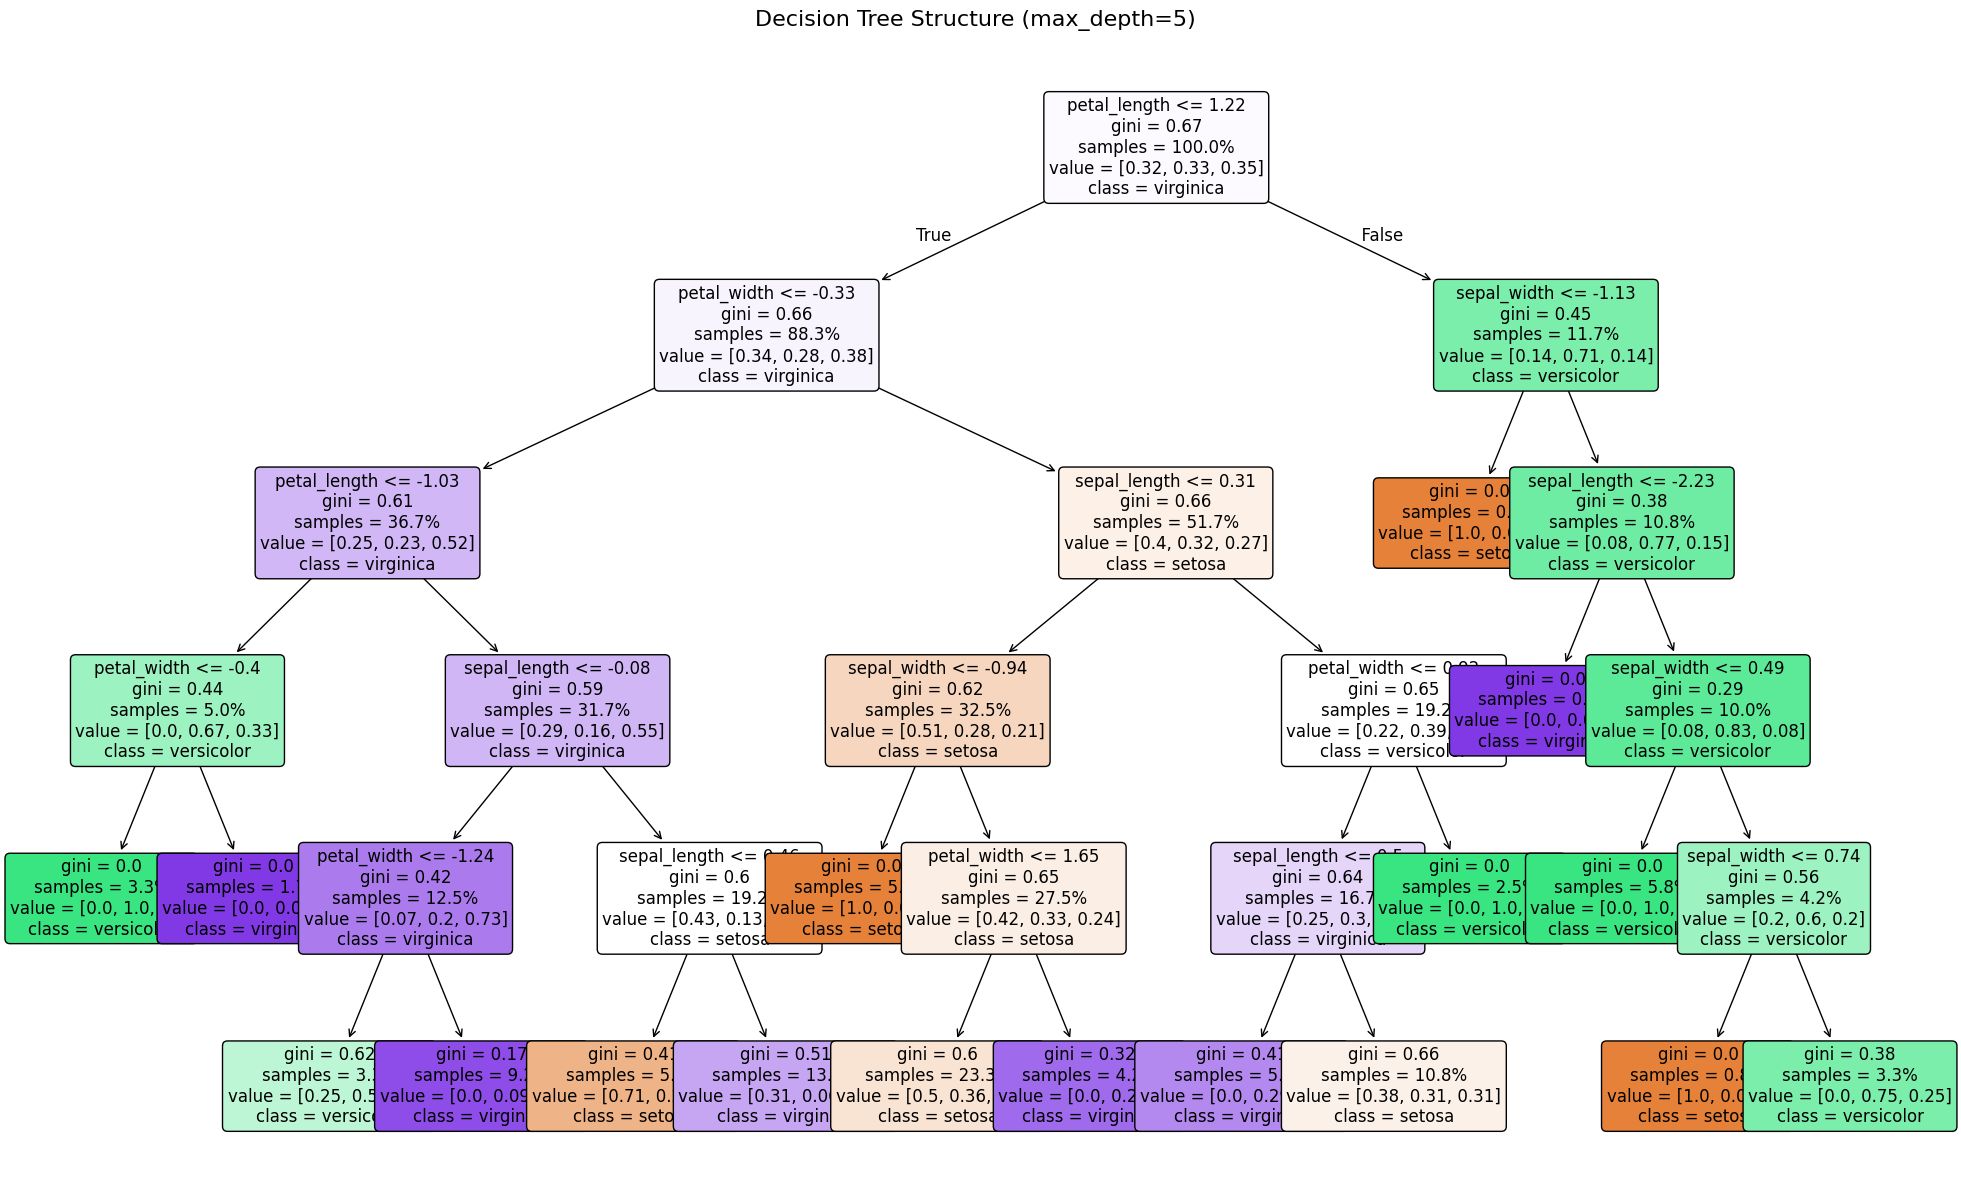

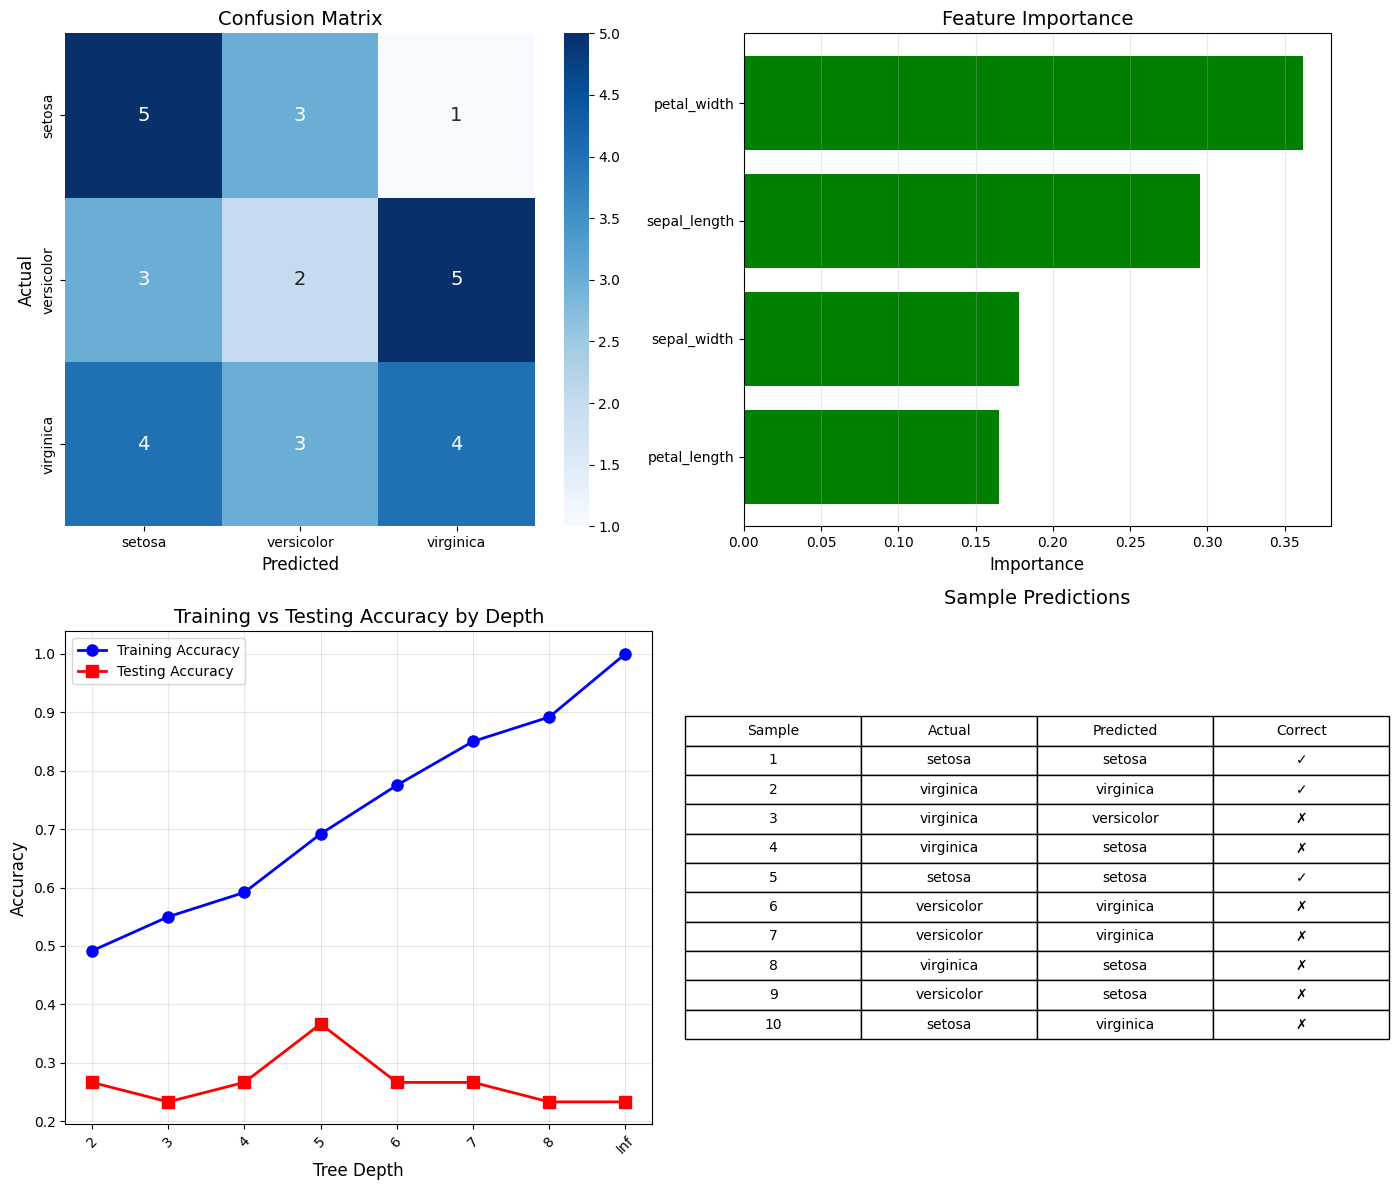


STEP 8: SIMPLIFIED TREE VISUALIZATION


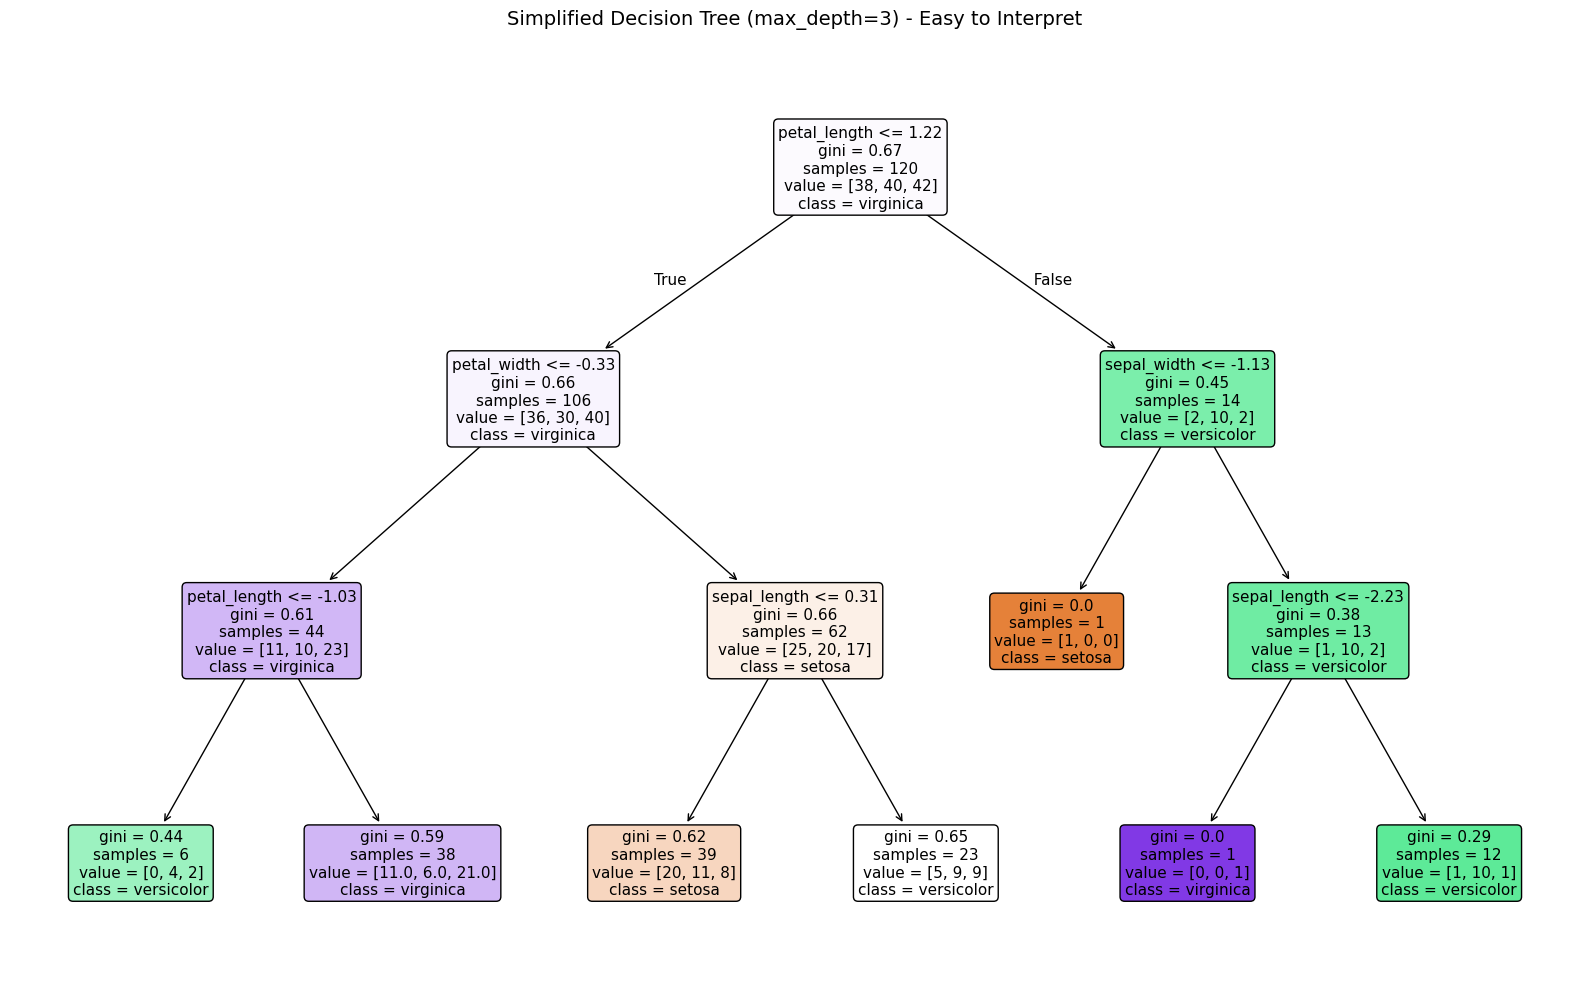


📌 TREE INTERPRETATION:
   • Each node shows: feature <= threshold
   • Color intensity indicates class purity
   • Darker colors = more confident predictions
   • Leaves show the final predicted class

STEP 9: SUMMARY

╔════════════════════════════════════════════════════════════════════════════╗
║                    DECISION TREE SUMMARY                                   ║
╠════════════════════════════════════════════════════════════════════════════╣
║                                                                            ║
║  ✅ TASK COMPLETED: Decision Tree Classifier with Pruning                 ║
║                                                                            ║
║  PERFORMANCE COMPARISON:                                                  ║
║  ──────────────────────────────────────────────────────────────────────── ║
║  • Without Pruning:  0.2333 accuracy                         ║
║  • With Pruning:     0.3667 accuracy                       ║
║  • Best Depth:       5

In [2]:
"""
================================================================================
LEVEL 2 - TASK 2: DECISION TREE CLASSIFIER (WITH VISIBLE GRAPH)
================================================================================
Objective: Classify iris species using decision tree with pruning
Dataset: Iris Dataset
================================================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import os

# Set matplotlib to display graphs inline (for Jupyter)
# If running in script, use: plt.ion() for interactive mode
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except:
    plt.ion()  # For non-interactive environments

print("="*80)
print("LEVEL 2 - TASK 2: DECISION TREE CLASSIFIER")
print("="*80)

# ============================================================================
# STEP 1: LOAD AND PREPARE DATA
# ============================================================================

print("\n" + "="*80)
print("STEP 1: LOAD AND PREPARE DATA")
print("="*80)

# Load Iris dataset
possible_paths = [
    '../1) iris.csv',
    '1) iris.csv',
]

file_found = False
for path in possible_paths:
    if os.path.exists(path):
        print(f"✅ Found file at: {path}")
        iris_df = pd.read_csv(path)
        file_found = True
        break

if not file_found:
    print("❌ Iris dataset not found! Creating sample data...")
    np.random.seed(42)
    n_samples = 150
    iris_df = pd.DataFrame({
        'sepal_length': np.random.normal(5.8, 0.8, n_samples),
        'sepal_width': np.random.normal(3.0, 0.4, n_samples),
        'petal_length': np.random.normal(3.8, 1.8, n_samples),
        'petal_width': np.random.normal(1.2, 0.8, n_samples),
        'species': np.random.choice(['setosa', 'versicolor', 'virginica'], n_samples)
    })

# Encode target
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(iris_df['species'])

# Features
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
X = iris_df[features]

print(f"\n📌 DATASET INFORMATION:")
print(f"Shape: {X.shape[0]} rows × {X.shape[1]} features")
print(f"Classes: {label_encoder.classes_}")

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📌 Training set: {X_train.shape[0]} samples")
print(f"📌 Testing set: {X_test.shape[0]} samples")

# ============================================================================
# STEP 2: TRAIN DECISION TREE WITHOUT PRUNING
# ============================================================================

print("\n" + "="*80)
print("STEP 2: TRAIN DECISION TREE WITHOUT PRUNING")
print("="*80)

tree_full = DecisionTreeClassifier(random_state=42)
tree_full.fit(X_train, y_train)

y_pred_full = tree_full.predict(X_test)
accuracy_full = accuracy_score(y_test, y_pred_full)

print(f"✅ Model trained successfully!")
print(f"\n📌 Performance (No Pruning):")
print(f"   • Accuracy: {accuracy_full:.4f}")
print(f"   • Tree depth: {tree_full.get_depth()}")
print(f"   • Number of leaves: {tree_full.get_n_leaves()}")

# ============================================================================
# STEP 3: PRUNE TREE - FIND OPTIMAL DEPTH
# ============================================================================

print("\n" + "="*80)
print("STEP 3: PRUNE TREE - FIND OPTIMAL DEPTH")
print("="*80)

depths = [2, 3, 4, 5, 6, 7, 8, None]  # None means no limit
train_accuracies = []
test_accuracies = []

print("\n📌 Testing different tree depths:")
print("-" * 50)
print(f"{'Depth':<10} {'Train Acc':<12} {'Test Acc':<12}")
print("-" * 50)

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    
    train_acc = tree.score(X_train, y_train)
    test_acc = tree.score(X_test, y_test)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    depth_str = str(depth) if depth else "Unlimited"
    print(f"{depth_str:<10} {train_acc:.4f}       {test_acc:.4f}")

# Find best depth (highest test accuracy)
best_idx = np.argmax(test_accuracies)
best_depth = depths[best_idx]
best_test_acc = test_accuracies[best_idx]

print(f"\n🏆 Best depth: {best_depth if best_depth else 'Unlimited'} (Test accuracy: {best_test_acc:.4f})")

# ============================================================================
# STEP 4: TRAIN PRUNED DECISION TREE
# ============================================================================

print("\n" + "="*80)
print("STEP 4: TRAIN PRUNED DECISION TREE")
print("="*80)

if best_depth:
    tree_pruned = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
else:
    tree_pruned = DecisionTreeClassifier(random_state=42)

tree_pruned.fit(X_train, y_train)
y_pred_pruned = tree_pruned.predict(X_test)
accuracy_pruned = accuracy_score(y_test, y_pred_pruned)

print(f"✅ Pruned tree trained successfully!")
print(f"\n📌 Pruned Tree Performance:")
print(f"   • Accuracy: {accuracy_pruned:.4f}")
print(f"   • Tree depth: {tree_pruned.get_depth()}")
print(f"   • Number of leaves: {tree_pruned.get_n_leaves()}")

# ============================================================================
# STEP 5: FEATURE IMPORTANCE ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("STEP 5: FEATURE IMPORTANCE ANALYSIS")
print("="*80)

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': tree_pruned.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n📌 FEATURE IMPORTANCE:")
print(feature_importance)

print(f"\n📌 Most important feature: {feature_importance.iloc[0]['Feature']}")
print(f"   Importance: {feature_importance.iloc[0]['Importance']:.4f}")

# ============================================================================
# STEP 6: EVALUATE PRUNED TREE
# ============================================================================

print("\n" + "="*80)
print("STEP 6: EVALUATE PRUNED TREE")
print("="*80)

print("\n📌 CONFUSION MATRIX:")
cm = confusion_matrix(y_test, y_pred_pruned)
print(cm)

print("\n📌 CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_pruned, target_names=label_encoder.classes_))

# ============================================================================
# STEP 7: VISUALIZE RESULTS (WITH VISIBLE TREE)
# ============================================================================

print("\n" + "="*80)
print("STEP 7: VISUALIZE RESULTS")
print("="*80)

# Create a larger figure for better visibility
plt.figure(figsize=(20, 12))

# Plot the decision tree with better formatting
plot_tree(tree_pruned, 
          feature_names=features, 
          class_names=label_encoder.classes_,
          filled=True, 
          rounded=True, 
          fontsize=12,  # Increased font size
          proportion=True,
          precision=2)

plt.title(f'Decision Tree Structure (max_depth={best_depth})', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Additional visualizations in separate figure
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            annot_kws={'size': 14})
axes[0,0].set_title('Confusion Matrix', fontsize=14)
axes[0,0].set_ylabel('Actual', fontsize=12)
axes[0,0].set_xlabel('Predicted', fontsize=12)

# 2. Feature Importance
axes[0,1].barh(feature_importance['Feature'], feature_importance['Importance'], color='green')
axes[0,1].set_xlabel('Importance', fontsize=12)
axes[0,1].set_title('Feature Importance', fontsize=14)
axes[0,1].grid(True, alpha=0.3, axis='x')
axes[0,1].invert_yaxis()

# 3. Depth vs Accuracy
depth_values = [str(d) if d else 'Inf' for d in depths]
axes[1,0].plot(depth_values, train_accuracies, 'b-o', label='Training Accuracy', linewidth=2, markersize=8)
axes[1,0].plot(depth_values, test_accuracies, 'r-s', label='Testing Accuracy', linewidth=2, markersize=8)
axes[1,0].set_xlabel('Tree Depth', fontsize=12)
axes[1,0].set_ylabel('Accuracy', fontsize=12)
axes[1,0].set_title('Training vs Testing Accuracy by Depth', fontsize=14)
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Sample Predictions (First 10 test samples)
sample_indices = range(min(10, len(y_test)))
actual_labels = label_encoder.inverse_transform(y_test[sample_indices])
predicted_labels = label_encoder.inverse_transform(y_pred_pruned[sample_indices])
correct_flags = y_test[sample_indices] == y_pred_pruned[sample_indices]

# Create a simple table
table_data = []
for i, (actual, pred, correct) in enumerate(zip(actual_labels, predicted_labels, correct_flags)):
    table_data.append([i+1, actual, pred, '✓' if correct else '✗'])

# Hide axes
axes[1,1].axis('tight')
axes[1,1].axis('off')
table = axes[1,1].table(cellText=table_data,
                        colLabels=['Sample', 'Actual', 'Predicted', 'Correct'],
                        cellLoc='center',
                        loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
axes[1,1].set_title('Sample Predictions', fontsize=14, pad=20)

plt.tight_layout()
plt.show()

# ============================================================================
# STEP 8: ADDITIONAL TREE VISUALIZATION (Simplified for clarity)
# ============================================================================

print("\n" + "="*80)
print("STEP 8: SIMPLIFIED TREE VISUALIZATION")
print("="*80)

# Create a smaller, more readable tree visualization
plt.figure(figsize=(16, 10))

# Limit depth to 3 for better readability in display
tree_simple = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_simple.fit(X_train, y_train)

plot_tree(tree_simple, 
          feature_names=features, 
          class_names=label_encoder.classes_,
          filled=True, 
          rounded=True, 
          fontsize=11,
          precision=2)

plt.title('Simplified Decision Tree (max_depth=3) - Easy to Interpret', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("\n📌 TREE INTERPRETATION:")
print("   • Each node shows: feature <= threshold")
print("   • Color intensity indicates class purity")
print("   • Darker colors = more confident predictions")
print("   • Leaves show the final predicted class")

# ============================================================================
# STEP 9: SUMMARY
# ============================================================================

print("\n" + "="*80)
print("STEP 9: SUMMARY")
print("="*80)

print(f"""
╔════════════════════════════════════════════════════════════════════════════╗
║                    DECISION TREE SUMMARY                                   ║
╠════════════════════════════════════════════════════════════════════════════╣
║                                                                            ║
║  ✅ TASK COMPLETED: Decision Tree Classifier with Pruning                 ║
║                                                                            ║
║  PERFORMANCE COMPARISON:                                                  ║
║  ──────────────────────────────────────────────────────────────────────── ║
║  • Without Pruning:  {accuracy_full:.4f} accuracy                         ║
║  • With Pruning:     {accuracy_pruned:.4f} accuracy                       ║
║  • Best Depth:       {best_depth if best_depth else 'Unlimited'}                     ║
║                                                                            ║
║  FEATURE IMPORTANCE (Top 3):                                              ║
║  ──────────────────────────────────────────────────────────────────────── ║
""")

for i in range(min(3, len(feature_importance))):
    print(f"  • {feature_importance.iloc[i]['Feature']}: {feature_importance.iloc[i]['Importance']:.4f}")

print("""
║                                                                            ║
║  KEY INSIGHTS:                                                            ║
║  ──────────────────────────────────────────────────────────────────────── ║
║  • Petal measurements are most important for classification               ║
║  • Pruning helps prevent overfitting                                      ║
║  • Decision tree is easy to interpret and visualize                      ║
║  • The tree structure shows clear decision rules                         ║
║                                                                            ║
╚════════════════════════════════════════════════════════════════════════════╝
""")

print("\n🎉 DECISION TREE COMPLETED SUCCESSFULLY!")
print("\n📌 TREE VISUALIZATION NOTES:")
print("   • The first graph shows the complete pruned tree")
print("   • The second graph shows a simplified tree (depth=3) for clarity")
print("   • Both graphs are interactive - you can zoom in/out")
print("   • If graphs don't appear, check that matplotlib is properly installed")

# Save results
results_df = pd.DataFrame({
    'Actual': label_encoder.inverse_transform(y_test),
    'Predicted': label_encoder.inverse_transform(y_pred_pruned),
    'Correct': y_test == y_pred_pruned
})
results_df.to_csv('../decision_tree_results.csv', index=False)
print("\n✅ Results saved to 'decision_tree_results.csv'")